## A Study of Gulf Stream Heat Content and Positional Variability in Relation to Sea Level Rise Along the North Atlantic East Coast

Gulf Stream variability has direct impacts on coastal sea level anomalies along the North Atlantic East Coast. However, the implications of heat content variability, in tandem with GS positional variability, in relation to coastal sea level rise is not yet apparent. In this project, I will aim to assess GS heat content as a variable in coastal steric sea level rise, and to utilize heat content trends to help better define/characterize GS intensity as it relates to sea level anomalies along the NA East Coast. Further, I hope to supplement these findings through the incorporation of a secondary analysis, examining the influences of GS positional variability (along an East/West axis, and a North/South axis) on coastal sea level rise. This study will aim to contextualize these influences within hyper-local sea level rise, examining these variables in relation to individual tide gauge stations. 

In [ ]:
%pip install copernicusmarine

## Initial GLORYS12 GS Data Import

In [ ]:
import copernicusmarine
import xarray as xr

# copernicus marine api documentation https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely

# loading data as xarray dataset via the copernicus marine api
ds = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m", # importing monthly data
    username="lchu1",
    password="AOSC445Project!",
    minimum_longitude = -98,
    maximum_longitude = -52,
    minimum_latitude = 26,
    maximum_latitude = 48,
    variables=["thetao", "zos", "uo", "vo"], # selecting specific variables for analysis
    start_datetime="1993-01-01", # setting data timeframe
    end_datetime="2024-12-15"
)

ds.head()

c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-05-09T01:23:29Z - Selected dataset version: "202311"
INFO - 2026-05-09T01:23:29Z - Selected dataset part: "default"


<xarray.Dataset> Size: 16kB
Dimensions:    (depth: 5, latitude: 5, longitude: 5, time: 5)
Coordinates:
  * depth      (depth) float32 20B 0.494 1.541 2.646 3.819 5.078
  * latitude   (latitude) float32 20B 26.0 26.08 26.17 26.25 26.33
  * longitude  (longitude) float32 20B -98.0 -97.92 -97.83 -97.75 -97.67
  * time       (time) datetime64[ns] 40B 1993-01-01 1993-02-01 ... 1993-05-01
Data variables:
    thetao     (time, depth, latitude, longitude) float64 5kB dask.array<chunksize=(5, 5, 5, 5), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 1kB dask.array<chunksize=(5, 5, 5), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 5kB dask.array<chunksize=(5, 5, 5, 5), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 5kB dask.array<chunksize=(5, 5, 5, 5), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLORYS12V1
    title:                         Monthly mean fields for product GLOBAL_REA...
    copernicusmarine_version:      2.4.0

Importing GLORYS12 reanalysis data from Copernicus Marine. 1/12 deg resolution. 

Structure includes 4 coords (time, depth, lat, long) and 4 data variables (pot temp, ssh, uo, vo). Pot temp across all 4 coords. ssh across lat, long, and time. uo/vo both across all 4 coords. Imported as an xarray dataset. 

In [ ]:
ds.dims

FrozenMappingWarningOnValuesAccess({'depth': 50, 'latitude': 265, 'longitude': 553, 'time': 384})

In [ ]:
type(ds)

xarray.core.dataset.Dataset

Similar to above, variables include thetao (potential heat, from which heat content + anomaly will be calculated), zos (sea surface height, from which sea level anomaly will be calculated), uo/vo (east/north velocity, to calculate speed). 

Dataset contains 50 depth values (in meters), 181 latitude values (in deg), 241 longitude values (in deg), and 384 time values (datetime). Potential heat in deg C, ssh in meters, and uo/vo in m/s. 

## Data Processing and Computation of Max Speed and Heat Content Variables

In [ ]:
# data cleaning

# coarsening for speed
gs_bound = ds.coarsen(latitude=2, longitude=2, boundary='trim').mean()

# interpolating nans
gs_bound = gs_bound.chunk(dict(time=-1)).interpolate_na(dim = 'time', method = 'linear')
# note: will also interpolate land values to 0, negligible because land now be represented by 0 instead of nan
# necessary for proper visualization without gaps


# naming variables and subsetting potential temp to select depth layers relevant for upper ocean analysis
# relevant for later heat content calculation
pot_t = gs_bound[['thetao']].sel(depth = slice(0,700)) # might change to 1000m?
pot_t

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 384, depth: 33, latitude: 132, longitude: 276)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
  * depth      (depth) float32 132B 0.494 1.541 2.646 ... 453.9 541.1 643.6
  * latitude   (latitude) float32 528B 26.04 26.21 26.38 ... 47.54 47.71 47.88
  * longitude  (longitude) float32 1kB -97.96 -97.79 -97.62 ... -52.29 -52.12
Data variables:
    thetao     (time, depth, latitude, longitude) float64 4GB dask.array<chunksize=(384, 33, 32, 128), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLORYS12V1
    title:                         Monthly mean fields for product GLOBAL_REA...
    copernicusmarine_version:      2.4.0

In [ ]:
# naming rest of the variables
ssh = gs_bound[['zos']]
n_vel = gs_bound[['vo']]
e_vel = gs_bound[['uo']]
# time in datetime, ssh in m, e vel in m/s, n vel in m/s, pot t in deg C


In [ ]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# potential temp to heat content
# compute layer thickness
dz = pot_t['depth'].diff('depth')
dz = dz.assign_coords(depth=pot_t['depth'][1:])

In [ ]:
# calculate heat content from potential temp
heat_content = 1025 * 3990 * pot_t['thetao'] * dz
# putting it back in the main dataset
total_heat = heat_content.sum(dim="depth")
gs_bound['heat_content'] = total_heat
gs_bound

<xarray.Dataset> Size: 17GB
Dimensions:       (depth: 50, latitude: 132, longitude: 276, time: 384)
Coordinates:
  * depth         (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude      (latitude) float32 528B 26.04 26.21 26.38 ... 47.71 47.88
  * longitude     (longitude) float32 1kB -97.96 -97.79 -97.62 ... -52.29 -52.12
  * time          (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
Data variables:
    thetao        (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    zos           (time, latitude, longitude) float64 112MB dask.array<chunksize=(384, 32, 128), meta=np.ndarray>
    uo            (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    vo            (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    heat_content  (time, latitude, longitude) float64 112MB dask.array<chunksize=(384, 32, 128), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLORYS12V1
    title:                         Monthly mean fields for product GLOBAL_REA...
    copernicusmarine_version:      2.4.0

In [ ]:
# computing speed for GS boundary contours
# taking max over all depths to isolate strongest parts of the stream
speed = np.sqrt((gs_bound['uo'] ** 2) + (gs_bound['vo'] ** 2)).max(dim = 'depth')
gs_bound['max_speed'] = speed
gs_bound

<xarray.Dataset> Size: 17GB
Dimensions:       (depth: 50, latitude: 132, longitude: 276, time: 384)
Coordinates:
  * depth         (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude      (latitude) float32 528B 26.04 26.21 26.38 ... 47.71 47.88
  * longitude     (longitude) float32 1kB -97.96 -97.79 -97.62 ... -52.29 -52.12
  * time          (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
Data variables:
    thetao        (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    zos           (time, latitude, longitude) float64 112MB dask.array<chunksize=(384, 32, 128), meta=np.ndarray>
    uo            (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    vo            (time, depth, latitude, longitude) float64 6GB dask.array<chunksize=(384, 50, 32, 128), meta=np.ndarray>
    heat_content  (time, latitude, longitude) float64 112MB dask.array<chunksize=(384, 32, 128), meta=np.ndarray>
    max_speed     (time, latitude, longitude) float64 112MB dask.array<chunksize=(384, 32, 128), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLORYS12V1
    title:                         Monthly mean fields for product GLOBAL_REA...
    copernicusmarine_version:      2.4.0

## Anomaly Computations

In [ ]:
# grouping data by month for monthly anomalies
monclim = gs_bound.groupby('time.month').mean('time')
monanom = gs_bound.groupby('time.month') - monclim

# yearly anomalies
yr_mean = gs_bound.resample(time='1YE').mean('time')
yr_anom = yr_mean - yr_mean.mean('time')

In [ ]:
# visual 1: heat content time series across entire study area 
anombox = monanom.sel(latitude = slice(26, 48), longitude = slice(-98, -52)).mean(dim = ['latitude', 'longitude'])
rolling = anombox.rolling(time = 12).mean()
rolling

<xarray.Dataset> Size: 476kB
Dimensions:       (depth: 50, time: 384)
Coordinates:
  * depth         (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * time          (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
    month         (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables:
    thetao        (time, depth) float64 154kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    zos           (time) float64 3kB dask.array<chunksize=(12,), meta=np.ndarray>
    uo            (time, depth) float64 154kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    vo            (time, depth) float64 154kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    heat_content  (time) float64 3kB dask.array<chunksize=(12,), meta=np.ndarray>
    max_speed     (time) float64 3kB dask.array<chunksize=(12,), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    dataset:                       global-reanalysis-001-030-monthly
    institution:                   Mercator Ocean
    ...                            ...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLORYS12V1
    title:                         Monthly mean fields for product GLOBAL_REA...
    copernicusmarine_version:      2.4.0

Text(0.5, 1.0, 'Heat Content Monthly Anomaly')

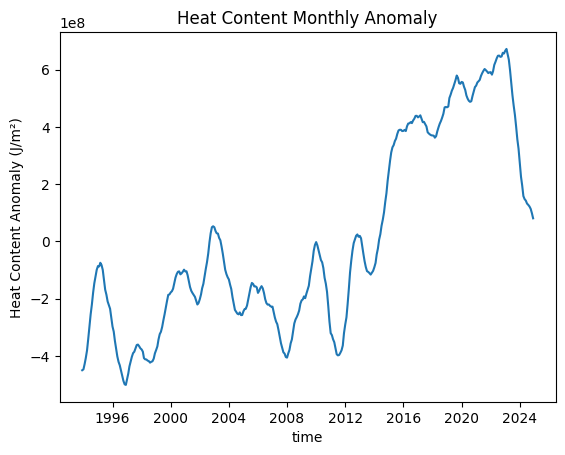

In [ ]:
# monthly anomalies time series
rolling['heat_content'].plot()
plt.xlabel('time')
plt.ylabel('Heat Content Anomaly (J/m²)')
plt.title('Heat Content Monthly Anomaly')

Text(0.5, 1.0, 'Heat content yearly anomally')

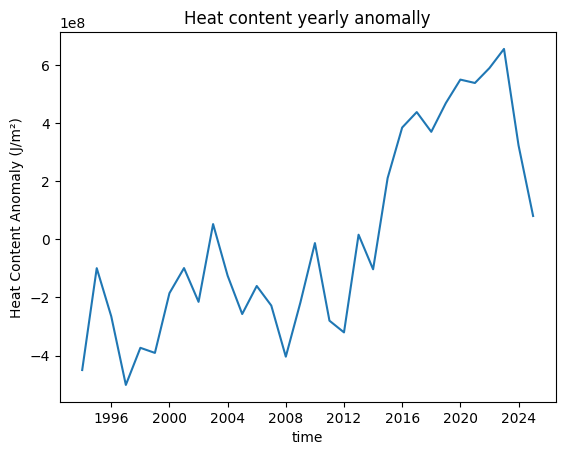

In [ ]:
# accuracy check against yr anoms for heat content
yr_anom['heat_content'].sel(latitude = slice(26, 48), longitude = slice(-98, -52)).mean(dim = ['latitude', 'longitude']).plot()
plt.xlabel('time')
plt.ylabel('Heat Content Anomaly (J/m²)')
plt.title('Heat content yearly anomally')

### Interpretation
The above plots display the monthly and yearly anomalies for heat content averaged across the entire study region (26 - 48 N, -98 - -52 E). This begins to address my original question by beginning to highlight long-term trends in the data (relevant for understanding exactly how the GS region is changing). An increasing heat content trend is apparent, mimicking the increasing trends in coastal sea level rise (shown in the plots below, although we do not yet know for sure if the two are directly correlated). Additionally, there is a sharp drop in the most recent data displayed on this plot, despite the overall warming trend. This is because the timeframe for the data cuts off midway through the last month, so total heat content (a sum) is appearing as roughly half of what it actually was by the end of the month. 

In [ ]:
# spaghetti plots setup
# goal: track movement of constant speed contours east/west at constant latitude over time for comparison with tide gauge data @ diff latitudes
# if time permits: redo for north/south at constant longitude

import pandas as pd

# create speed east/west spatial deviation dataset (dims = time, long) across constant latitudes
gs_cores = gs_bound['max_speed'].idxmax(dim = 'longitude', skipna = True) # longitude where max speed occurs @ lat @ time
gs_core = gs_cores.mean(dim = 'time', skipna = True) # mean positional longitude of max speed @ lat across time
gs_core_dev_ew = gs_cores - gs_core # longitudinal deviation from mean longitude @ lat @ time

gs_core_dev_ew


<xarray.DataArray 'longitude' (time: 384, latitude: 132)> Size: 203kB
dask.array<sub, shape=(384, 132), dtype=float32, chunksize=(384, 32), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
  * latitude  (latitude) float32 528B 26.04 26.21 26.38 ... 47.54 47.71 47.88
Attributes:
    cell_methods:  area: mean
    unit_long:     Meters per second
    units:         m s-1

In [ ]:
# spaghetti plots setup for north/south at constant longitude

# create speed north/south spatial deviation dataset (dims = time, lat) across constant longitudes
gs_cores_ns = gs_bound['max_speed'].idxmax(dim = 'latitude', skipna = True) # latitude where max speed occurs @ long @ time
gs_core_ns = gs_cores_ns.mean(dim = 'time', skipna = True) # mean positional latitude of max speed @ long across time
gs_core_dev_ns = gs_cores_ns - gs_core_ns # latitudinal deviation from mean latitude @ long @ time

gs_core_dev_ns

<xarray.DataArray 'latitude' (time: 384, longitude: 276)> Size: 424kB
dask.array<sub, shape=(384, 276), dtype=float32, chunksize=(384, 128), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2024-12-01
  * longitude  (longitude) float32 1kB -97.96 -97.79 -97.62 ... -52.29 -52.12
Attributes:
    cell_methods:  area: mean
    unit_long:     Meters per second
    units:         m s-1

## Tide Gauge Data Import and Handling

In [ ]:
# tide gauge data import
import pandas as pd
import requests as req
url = "https://api.github.com/repos/lindsnch/lindsnch_slr_research/contents/Monthly_Data_Files/Northeast_csvs"
files = req.get(url).json()

dfs = []
for file in files:
    fileurl = file['download_url']
    station = file['name'].replace('_Monthly_Cleaned.csv', '').replace('_Cleaned_Monthly.csv', '')
    df = pd.read_csv(fileurl)
    df['Station_Name'] = station
    df['Date'] = pd.to_datetime(df['Date'], format = 'mixed')
    dfs.append(df)

all_stat = pd.concat(dfs)
all_stat['Station_Name'].nunique()

52

In [ ]:
dfs[1].head()

,Date,SeaLevel,Issues,Station_Name
0,1967-05-16 21:00:00,6873.0,0,Apalachicola
1,1967-06-16 06:42:28,6940.0,0,Apalachicola
2,1967-07-16 17:17:31,6910.0,0,Apalachicola
3,1967-08-16 03:00:00,6965.0,0,Apalachicola
4,1967-09-15 12:42:28,6953.0,0,Apalachicola


In [ ]:
# anomalies
slclim = all_stat.groupby(['Station_Name', all_stat['Date'].dt.month])['SeaLevel'].mean()
slclim.index.names = ['Station', 'Month']

all_stat['Month'] = all_stat['Date'].dt.month
all_stat = all_stat.join(slclim.rename('Clim'), on = ['Station_Name', 'Month'])
all_stat['SLAnom'] = all_stat['SeaLevel'] - all_stat['Clim']

all_stat.head()

,Date,SeaLevel,Issues,Station_Name,Month,Clim,SLAnom
0,1928-09-15 05:42:25,6918.0,0,Annapolis,9,7104.623656,-186.623656
1,1928-10-15 18:17:34,6824.0,0,Annapolis,10,7062.838710,-238.838710
2,1928-11-15 06:00:00,6662.0,0,Annapolis,11,6981.430108,-319.430108
3,1928-12-15 17:42:25,6668.0,0,Annapolis,12,6898.097826,-230.097826
4,1929-01-15 05:17:31,6531.0,0,Annapolis,1,6867.225806,-336.225806


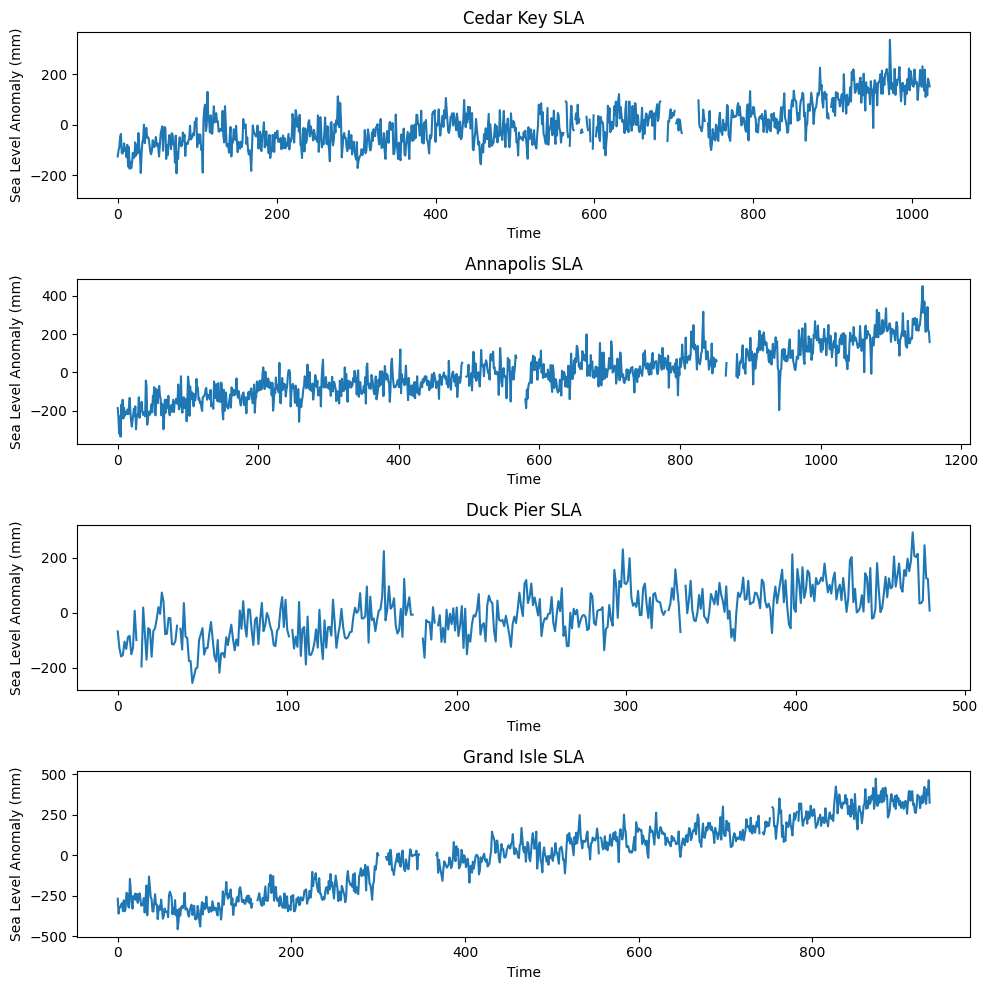

In [ ]:
# test plot
from matplotlib import pyplot as plt
fig, ax = plt.subplots(4, 1, figsize=(10, 10))

all_stat[all_stat['Station_Name'] == 'CedarKey']['SLAnom'].plot(ax = ax[0])
ax[0].set_title('Cedar Key SLA')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Sea Level Anomaly (mm)')

all_stat[all_stat['Station_Name'] == 'Annapolis']['SLAnom'].plot(ax = ax[1])
ax[1].set_title('Annapolis SLA')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Sea Level Anomaly (mm)')

all_stat[all_stat['Station_Name'] == 'DuckPierOutside']['SLAnom'].plot(ax = ax[2])
ax[2].set_title('Duck Pier SLA')
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Sea Level Anomaly (mm)')

all_stat[all_stat['Station_Name'] == 'GrandIsle']['SLAnom'].plot(ax = ax[3])
ax[3].set_title('Grand Isle SLA')
ax[3].set_xlabel('Time')
ax[3].set_ylabel('Sea Level Anomaly (mm)')

plt.tight_layout()


### Interpretation

These plots display examples of SLA at each tide gauge station over time. These can be compared to the Gulf Stream position spaghetti plot and the heat content anomaly plot to visually see if there is a correlation between the each variable over time (prior to correlation analyses). Based on visuals alone, both the tide gauge sea level anomalies and the heat content anomalies display an increasing trend over time, whereas the GS position plot (below) does not appear to have a strong correlation trend with the tide gauge sea level anomalies over time. 

In [ ]:
# tide gauge location data import
import pandas as pd
llurl = "https://raw.githubusercontent.com/lindsnch/lindsnch_slr_research/main//station_latlongs.csv"
ll = pd.read_csv(llurl)
ll['Station_Name'] = ll['Station_Name'].str.replace('. ', '')
ll['Station_Name'] = ll['Station_Name'].str.replace(' ', '')
ll['Station_Name'] = ll['Station_Name'].str.replace('-', '')
ll['Station_Name'] = ll['Station_Name'].str.replace("'", "")
ll['Station_Name'] = ll['Station_Name'].str.replace('II', '')
ll['Station_Name'] = ll['Station_Name'].str.replace('DuckPier', 'DuckPierOutside')
ll['Station_Name'] = ll['Station_Name'].str.replace('(Miami)', '')
ll['Station_Name'] = ll['Station_Name'].str.replace('(PalmBeach)', '')
ll = ll[(ll['Lat'] >= 26) & (ll['Lat'] <= 48) & (ll['Long'] >= -98) & (ll['Long'] <= -52)] # only stations in imported GS area (this line may be leftover from an earlier iteration where the study area was smaller for memory reasons but I am leaving it here because I am scared to take it out)
ll

,Station_Name,State_Abbr,Lat,Long
0,PortIsabel,TX,26.060000,-97.215000
1,Rockport,TX,28.021667,-97.046667
2,Galveston,TX,29.310000,-94.793333
3,GrandIsle,LA,29.263333,-89.956667
4,NewCanalStation,LA,30.026667,-90.113333
5,Pensacola,FL,30.403333,-87.210000
6,DauphinIsland,AL,30.250000,-88.075000
7,Apalachicola,FL,29.726667,-84.981667
8,CedarKey,FL,29.135000,-83.031667
9,StPetersburg,FL,27.760000,-82.626667


In [ ]:
# gettin' the lat/longs in there
dfull = all_stat.merge(ll, on = 'Station_Name')
dfull

,Date,SeaLevel,Issues,Station_Name,Month,Clim,SLAnom,State_Abbr,Lat,Long
0,1928-09-15 05:42:25,6918.0,0,Annapolis,9,7104.623656,-186.623656,MD,38.983333,-76.480000
1,1928-10-15 18:17:34,6824.0,0,Annapolis,10,7062.838710,-238.838710,MD,38.983333,-76.480000
2,1928-11-15 06:00:00,6662.0,0,Annapolis,11,6981.430108,-319.430108,MD,38.983333,-76.480000
3,1928-12-15 17:42:25,6668.0,0,Annapolis,12,6898.097826,-230.097826,MD,38.983333,-76.480000
4,1929-01-15 05:17:31,6531.0,0,Annapolis,1,6867.225806,-336.225806,MD,38.983333,-76.480000
...,...,...,...,...,...,...,...,...,...,...
39571,2024-08-15 18:00:00,7151.0,0,Yarmouth,8,6979.888889,171.111111,Nova Scotia,43.833333,-66.133333
39572,2024-09-15 05:42:25,7201.0,0,Yarmouth,9,7000.090909,200.909091,Nova Scotia,43.833333,-66.133333
39573,2024-10-15 18:17:34,7191.0,0,Yarmouth,10,7032.481481,158.518519,Nova Scotia,43.833333,-66.133333
39574,2024-11-15 06:00:00,7251.0,0,Yarmouth,11,7041.181818,209.818182,Nova Scotia,43.833333,-66.133333


In [ ]:
# function to locate nearest lat in gs bound dataset

def nearestlat(stationlat, gslat):
    return gslat[np.argmin(np.abs(gslat - stationlat))]

gslat = gs_core_dev_ew.latitude.values
dfull['NearLat'] = dfull['Lat'].apply(lambda x: nearestlat(x, gslat))

In [ ]:
# function to locate nearest long in gs bound dataset

def nearestlong(stationlong, gslong):
    return gslong[np.argmin(np.abs(gslong - stationlong))]

gslong = gs_core_dev_ns.longitude.values
dfull['NearLong'] = dfull['Long'].apply(lambda x: nearestlong(x, gslong))

In [ ]:
dfull

,Date,SeaLevel,Issues,Station_Name,Month,Clim,SLAnom,State_Abbr,Lat,Long,NearLat,NearLong
0,1928-09-15 05:42:25,6918.0,0,Annapolis,9,7104.623656,-186.623656,MD,38.983333,-76.480000,39.041664,-76.458328
1,1928-10-15 18:17:34,6824.0,0,Annapolis,10,7062.838710,-238.838710,MD,38.983333,-76.480000,39.041664,-76.458328
2,1928-11-15 06:00:00,6662.0,0,Annapolis,11,6981.430108,-319.430108,MD,38.983333,-76.480000,39.041664,-76.458328
3,1928-12-15 17:42:25,6668.0,0,Annapolis,12,6898.097826,-230.097826,MD,38.983333,-76.480000,39.041664,-76.458328
4,1929-01-15 05:17:31,6531.0,0,Annapolis,1,6867.225806,-336.225806,MD,38.983333,-76.480000,39.041664,-76.458328
...,...,...,...,...,...,...,...,...,...,...,...,...
39571,2024-08-15 18:00:00,7151.0,0,Yarmouth,8,6979.888889,171.111111,Nova Scotia,43.833333,-66.133333,43.875000,-66.125000
39572,2024-09-15 05:42:25,7201.0,0,Yarmouth,9,7000.090909,200.909091,Nova Scotia,43.833333,-66.133333,43.875000,-66.125000
39573,2024-10-15 18:17:34,7191.0,0,Yarmouth,10,7032.481481,158.518519,Nova Scotia,43.833333,-66.133333,43.875000,-66.125000
39574,2024-11-15 06:00:00,7251.0,0,Yarmouth,11,7041.181818,209.818182,Nova Scotia,43.833333,-66.133333,43.875000,-66.125000


In [ ]:
# pre-computing for speed and memory issue workaround
gs_core_dev_ew_computed = gs_core_dev_ew.compute()

c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)


In [ ]:
gs_core_dev_ns_computed = gs_core_dev_ns.compute()

c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
c:\Users\LindsayChu\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\dask\array\reductions.py:784: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)


## Spaghetti Plots 

### East/West Deviation of GS Core Position 

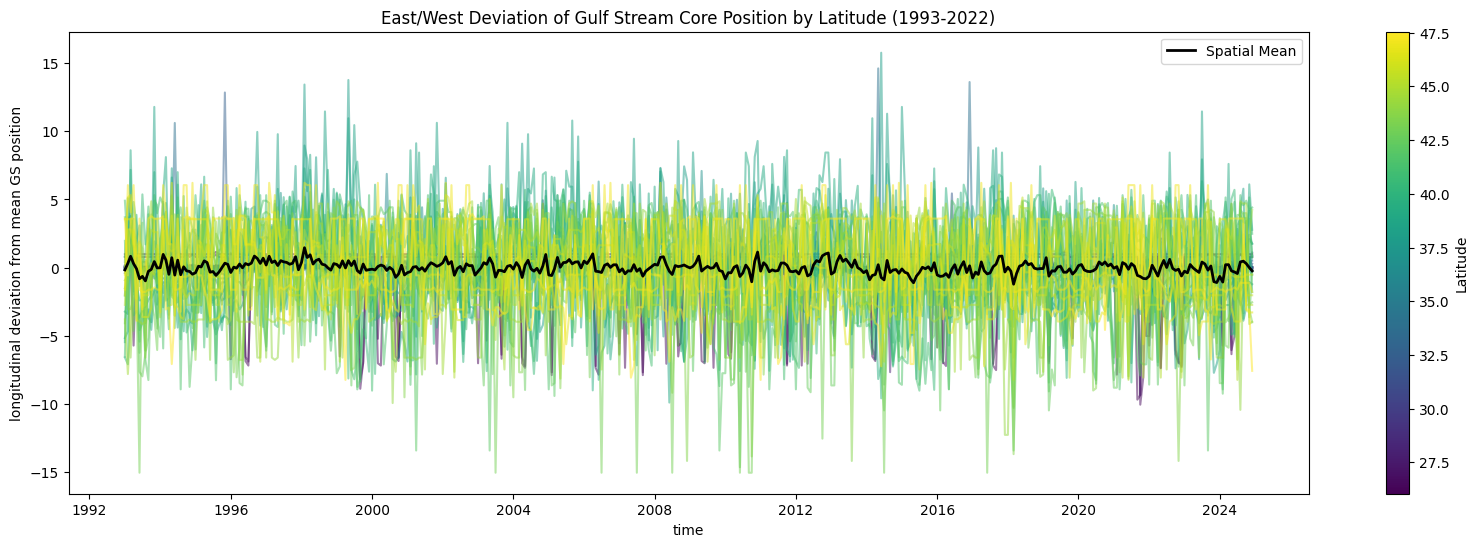

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(20, 6))

lats = gs_core_dev_ew_computed.latitude.values[::3]
cmap = plt.get_cmap('viridis') # documentationnnn https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.get_cmap.html 
norm = plt.Normalize(vmin=lats.min(), vmax=lats.max())

for lat in lats:
    dev = gs_core_dev_ew_computed.sel(latitude=lat, method='nearest')
    ax.plot(gs_core_dev_ew_computed.time.values, dev.values, color=cmap(norm(lat)), alpha=0.5)

scamap = plt.cm.ScalarMappable(cmap=cmap, norm=norm) # more docs https://matplotlib.org/stable/api/cm_api.html 
fig.colorbar(scamap, ax=ax, label='Latitude')
ax.plot(gs_core_dev_ew_computed.time.values, gs_core_dev_ew_computed.mean(dim='latitude').values, color='black', linewidth=2, label='Spatial Mean')

ax.set_title('East/West Deviation of Gulf Stream Core Position by Latitude (1993-2022)')
ax.set_xlabel('time')
ax.set_ylabel('longitudinal deviation from mean GS position')
ax.legend()
plt.show()

### North/South Deviation of GS Core Position 

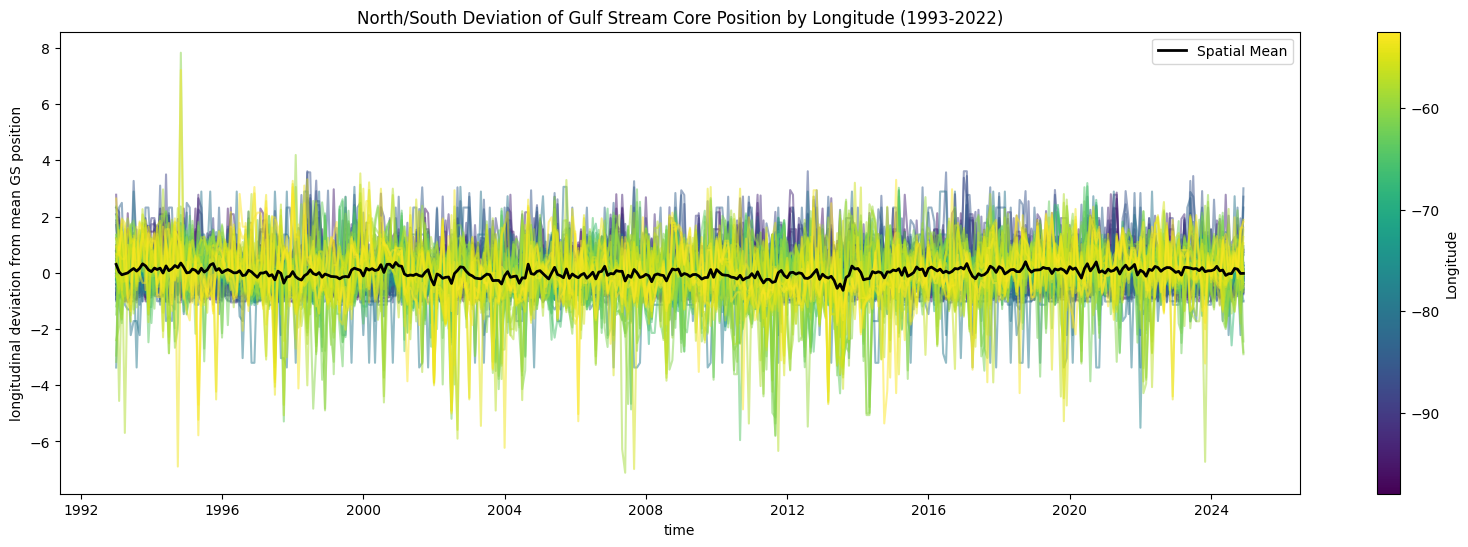

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(20, 6))

longs = gs_core_dev_ns_computed.longitude.values[::3]
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=longs.min(), vmax=longs.max())

for long in longs:
    dev = gs_core_dev_ns_computed.sel(longitude=long, method='nearest')
    ax.plot(gs_core_dev_ns_computed.time.values, dev.values, color=cmap(norm(long)), alpha=0.5)


scamap = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(scamap, ax=ax, label='Longitude')
ax.plot(gs_core_dev_ns_computed.time.values, gs_core_dev_ns_computed.mean(dim='longitude').values, color='black', linewidth=2, label='Spatial Mean')

ax.set_title('North/South Deviation of Gulf Stream Core Position by Longitude (1993-2022)')
ax.set_xlabel('time')
ax.set_ylabel('longitudinal deviation from mean GS position')
ax.legend()
plt.show()

### Interpretation
The figures above display the East/West and North/South deviations of the GS core, by change in longitude and latitude respectively. The mean GS core movement is displayed as a black line. This provides an understanding as to the general positional variation of the GS core across time, and across different regions. Based on the East/West plot, it may be concluded that the GS core generally varies less from East to West at higher latitudes (further North) than at lower latitudes (further South). The North/South plot indicates that the GS may demonstrate more significant shifts Southward at high longitudes (further East) than at lower longitudes (further West). Further, there appears to be a larger variation in East/West position than North/South, as indicated by the difference in ranges between the two plots. 

## Correlation Computations 

In [ ]:

results_lat = []
for station, group in dfull.groupby('Station_Name'):  
    lat = group['NearLat'].iloc[0]
    gsnomnom = gs_core_dev_ew_computed.sel(latitude = lat).to_dataframe(name = 'nomnomnom').reset_index()

    # normalizing both to month-start so merge matches, used AI to help debug the time formatting for this section
    gsnomnom['time'] = gsnomnom['time'].dt.to_period('M').dt.to_timestamp()
    tgnomnom = group[['Date', 'SLAnom']].copy()
    tgnomnom['Date'] = tgnomnom['Date'].dt.to_period('M').dt.to_timestamp()

    # nomnomnom 
    omnomnom = tgnomnom.merge(gsnomnom, left_on = 'Date', right_on = 'time').dropna(subset = ['SLAnom', 'nomnomnom'])
    correlate = omnomnom['SLAnom'].corr(omnomnom['nomnomnom'])  # omnomnomnomnomnom lol
    results_lat.append({'Station': station, 'Lat': lat, 'Corr': correlate}) # concat not working here?? appending to list and then converting to df instead

corr = pd.DataFrame(results_lat)
corr.head()

,Station,Lat,Corr
0,Annapolis,39.041664,0.007957
1,Apalachicola,29.708332,0.065085
2,AtlanticCity,39.375000,-0.012028
3,BarHarbor,44.375000,0.075938
4,Beaufort,34.708336,-0.110850


In [ ]:

results_long = []
for station, group in dfull.groupby('Station_Name'):  
    lat = group['NearLat'].iloc[0]
    long = group['NearLong'].iloc[0]
    gsnomnom = gs_core_dev_ns_computed.sel(longitude = long).to_dataframe(name='nomnomnom').reset_index()

    # normalizing both to month-start so merge matches, used AI to help debug the time formatting for this section
    gsnomnom['time'] = gsnomnom['time'].dt.to_period('M').dt.to_timestamp()
    tgnomnom = group[['Date', 'SLAnom']].copy()
    tgnomnom['Date'] = tgnomnom['Date'].dt.to_period('M').dt.to_timestamp()

    # nomnomnom 
    omnomnom = tgnomnom.merge(gsnomnom, left_on = 'Date', right_on = 'time').dropna(subset = ['SLAnom', 'nomnomnom'])
    correlate = omnomnom['SLAnom'].corr(omnomnom['nomnomnom'])  # omnomnomnomnomnom lol
    results_long.append({'Station': station, 'Lat': lat, 'Corr': correlate}) # concat not working here?? appending to list and then converting to df instead

corr_long = pd.DataFrame(results_long)
corr_long.head()

,Station,Lat,Corr
0,Annapolis,39.041664,0.018935
1,Apalachicola,29.708332,0.027178
2,AtlanticCity,39.375000,0.007966
3,BarHarbor,44.375000,-0.046749
4,Beaufort,34.708336,-0.100956


In [ ]:
# basin-wide heat content anomaly vs sea level anomaly at each station
basin_hc = monanom['heat_content'].mean(dim=['latitude', 'longitude'])
basin_df = basin_hc.to_dataframe(name='HeatContentAnom').reset_index()
basin_df['time'] = basin_df['time'].dt.to_period('M').dt.to_timestamp()

basin_results = []
for station, group in dfull.groupby('Station_Name'):
    lat = group['NearLat'].iloc[0]
    tgnomnom = group[['Date', 'SLAnom']].copy()
    tgnomnom['Date'] = tgnomnom['Date'].dt.to_period('M').dt.to_timestamp() # used AI to help debug time for this section as well

    omnomnom = tgnomnom.merge(basin_df, left_on='Date', right_on='time').dropna(subset=['SLAnom', 'HeatContentAnom'])
    correlate = omnomnom['SLAnom'].corr(omnomnom['HeatContentAnom'])
    basin_results.append({'Station': station, 'Lat': lat, 'Corr': correlate})

corr_hc_basin = pd.DataFrame(basin_results)
corr_hc_basin.head()

,Station,Lat,Corr
0,Annapolis,39.041664,0.494397
1,Apalachicola,29.708332,0.682495
2,AtlanticCity,39.375000,0.434574
3,BarHarbor,44.375000,0.385813
4,Beaufort,34.708336,0.628491


In [ ]:
# station-matched (BY LAT) heat content anomaly vs sea level anomaly
hc_lat = monanom['heat_content'].mean(dim='longitude').compute() 

matched = []
for station, group in dfull.groupby('Station_Name'):
    lat = group['NearLat'].iloc[0]

    # heat content at nearest latitude, averaged across longitude
    hc_at_lat =hc_lat.sel(latitude=lat, method='nearest')
    hc_df = hc_at_lat.to_dataframe(name='HeatContentAnom').reset_index()
    hc_df['time'] = hc_df['time'].dt.to_period('M').dt.to_timestamp()

    tgnomnom = group[['Date', 'SLAnom']].copy()
    tgnomnom['Date'] = tgnomnom['Date'].dt.to_period('M').dt.to_timestamp()

    omnomnom = tgnomnom.merge(hc_df, left_on='Date', right_on='time').dropna(subset=['SLAnom', 'HeatContentAnom'])
    correlate = omnomnom['SLAnom'].corr(omnomnom['HeatContentAnom'])
    matched.append({'Station': station, 'Lat': lat, 'Corr': correlate})

corr_hc_matched = pd.DataFrame(matched)
corr_hc_matched.head()

,Station,Lat,Corr
0,Annapolis,39.041664,0.181355
1,Apalachicola,29.708332,0.618922
2,AtlanticCity,39.375000,0.143232
3,BarHarbor,44.375000,0.379193
4,Beaufort,34.708336,0.515528


## Final Correlation Plots

C:\Users\LindsayChu\AppData\Local\Temp\ipykernel_38044\3288080251.py:12: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax[0, 0].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8) # first time using annotate lol https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html
C:\Users\LindsayChu\AppData\Local\Temp\ipykernel_38044\3288080251.py:25: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax[0, 1].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8)
C:\Users\LindsayChu\AppData\Local\Temp\ipykernel_38044\3288080251.py:38: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax[1, 0].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8)
C:\Use

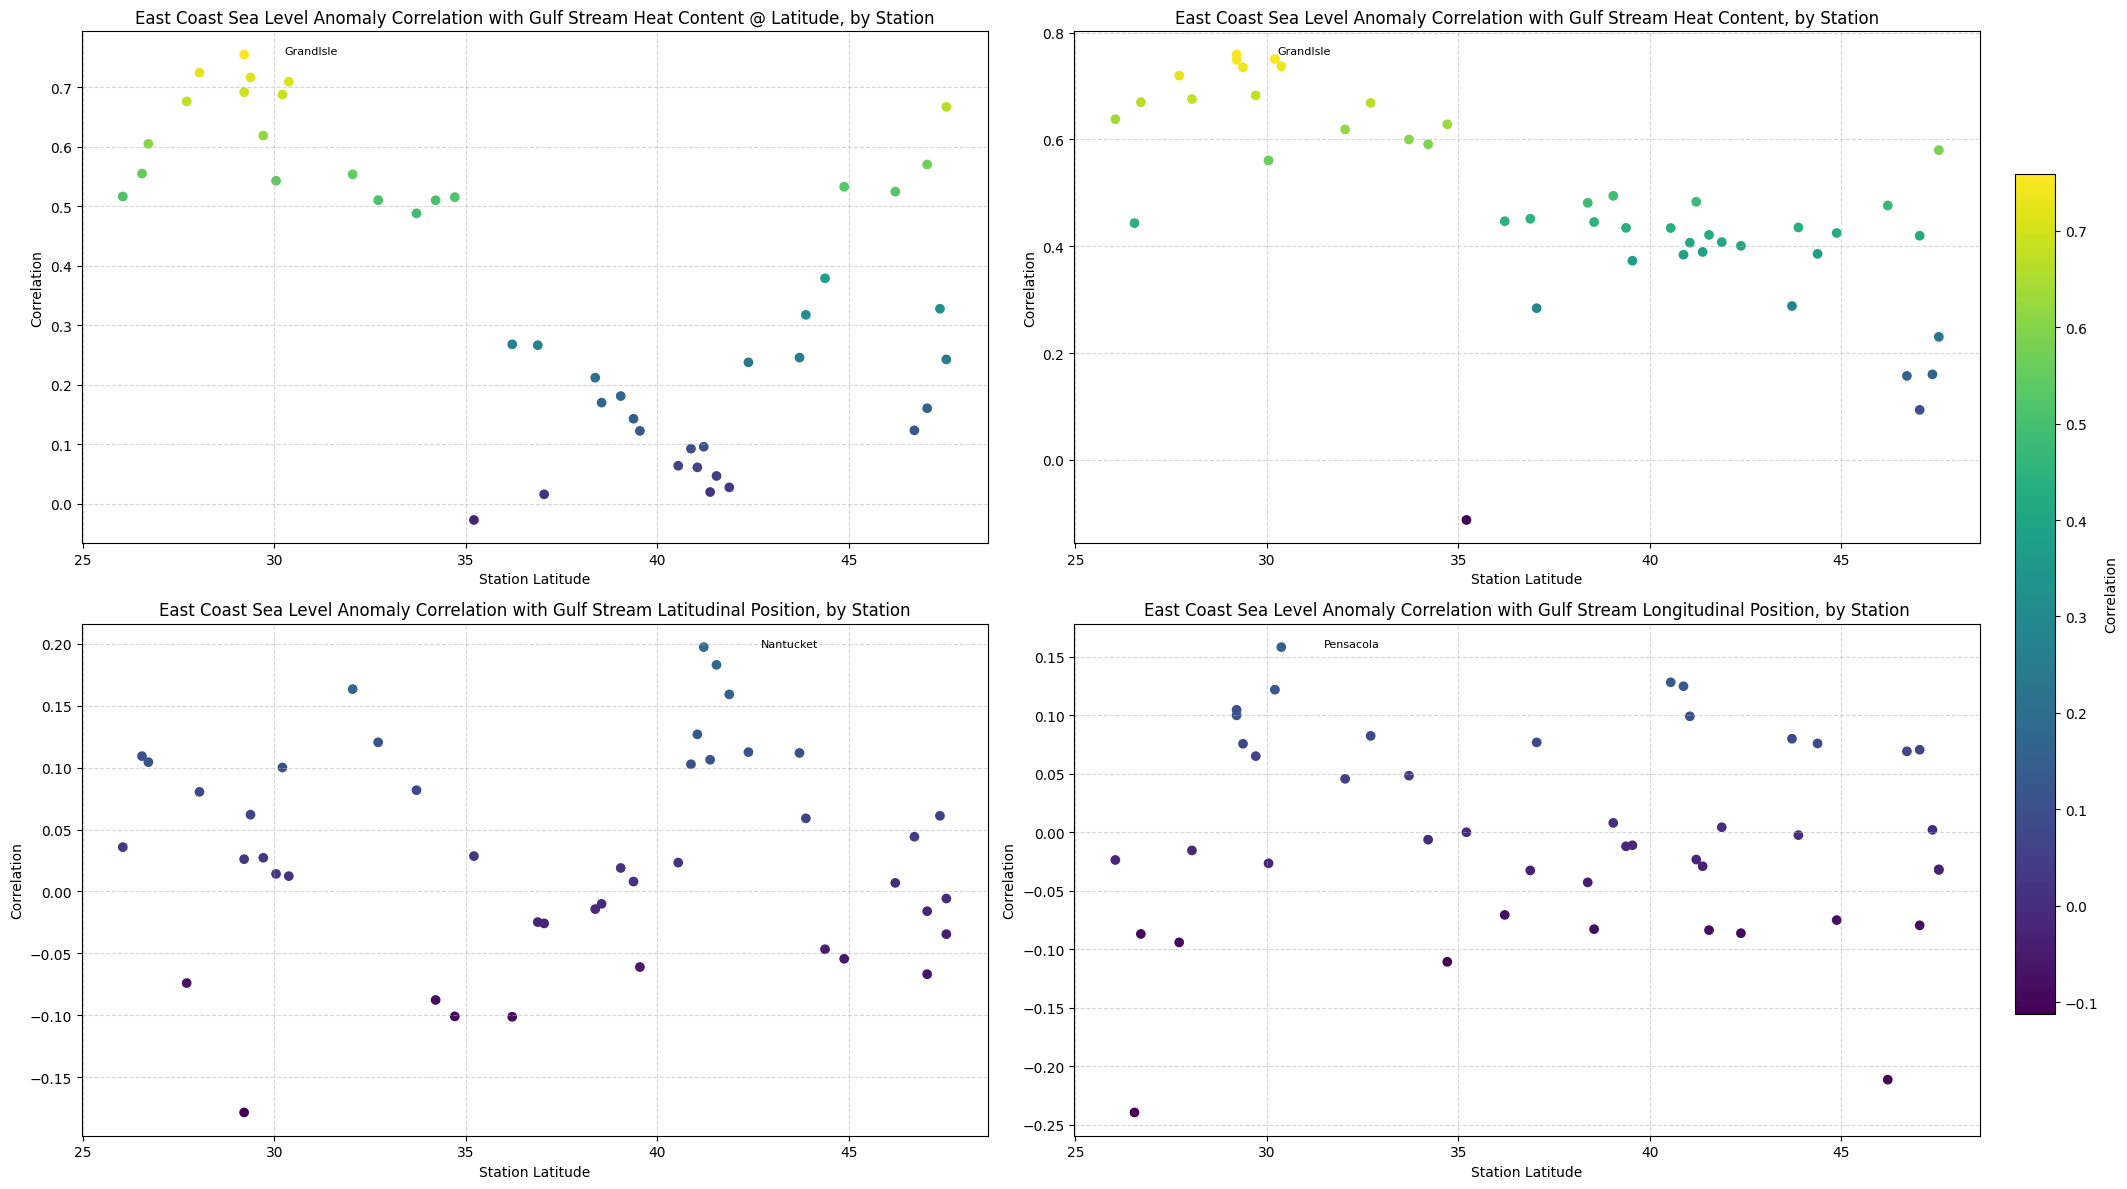

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

all_corrs = pd.concat([corr_hc_matched['Corr'], corr_hc_basin['Corr']])
norm = plt.Normalize(vmin=all_corrs.min(), vmax=all_corrs.max())
cmap = cm.viridis


ax[0, 0].scatter(corr_hc_matched['Lat'], corr_hc_matched['Corr'], c = corr_hc_matched['Corr'], cmap=cmap, norm=norm)

top_hc_matched = corr_hc_matched.nlargest(1, 'Corr')
for _, row in top_hc_matched.iterrows():
    ax[0, 0].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8) # first time using annotate lol https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html
    
ax[0, 0].set_title('East Coast Sea Level Anomaly Correlation with Gulf Stream Heat Content @ Latitude, by Station')
ax[0, 0].set_xlabel('Station Latitude')
ax[0, 0].set_ylabel('Correlation')
ax[0, 0].grid(True, linestyle='--', alpha=0.5)

# ----- separator for sanity -----

ax[0, 1].scatter(corr_hc_basin['Lat'], corr_hc_basin['Corr'], c = corr_hc_basin['Corr'], cmap=cmap, norm=norm)

top_hc_basin = corr_hc_basin.nlargest(1, 'Corr')
for _, row in top_hc_basin.iterrows():
    ax[0, 1].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8)

ax[0, 1].set_title('East Coast Sea Level Anomaly Correlation with Gulf Stream Heat Content, by Station')
ax[0, 1].set_xlabel('Station Latitude')
ax[0, 1].set_ylabel('Correlation')
ax[0, 1].grid(True, linestyle='--', alpha=0.5)

# ----- separator for sanity -----

ax[1, 0].scatter(corr_long['Lat'], corr_long['Corr'], c = corr_long['Corr'], cmap=cmap, norm=norm)

top_corr_long = corr_long.nlargest(1, 'Corr')
for _, row in top_corr_long.iterrows():
    ax[1, 0].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8)

ax[1, 0].set_title('East Coast Sea Level Anomaly Correlation with Gulf Stream Latitudinal Position, by Station')
ax[1, 0].set_xlabel('Station Latitude')
ax[1, 0].set_ylabel('Correlation')
ax[1, 0].grid(True, linestyle='--', alpha=0.5)

# ----- separator for sanity -----

ax[1, 1].scatter(corr['Lat'], corr['Corr'], c = corr['Corr'], cmap=cmap, norm=norm)

top_corr = corr.nlargest(1, 'Corr')
for _, row in top_corr.iterrows():
    ax[1, 1].annotate(row['Station'], xy=(row['Lat'], row['Corr']), textcoords='offset points', fontsize=8)
    
ax[1, 1].set_title('East Coast Sea Level Anomaly Correlation with Gulf Stream Longitudinal Position, by Station')
ax[1, 1].set_xlabel('Station Latitude')    
ax[1, 1].set_ylabel('Correlation')
ax[1, 1].grid(True, linestyle='--', alpha=0.5)

# ----- separator for sanity -----

scamap = cm.ScalarMappable(cmap=cmap, norm=norm)
scamap.set_array([])
cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.add_axes.html 
fig.colorbar(scamap, cax=cbar_ax, label='Correlation')

plt.tight_layout()


### Interpretation

The plots above display the results of the cross correlation analysis between sea level anomalies at each station (by latitude) and each of the four variables (heat content across the entire basin included in the study area, heat content at each station's corresponding latitude, GS core North/South deviation, and GS core East/West deviation). It is shown that there is little correlation between SLA at the stations and East/Westward deviation of the GS core position by latitude. There is slightly higher (although still very weak) correlation between SLA at some of the stations and the North/South deviation of the GS core position by longitude. There is also an apparent trend in these correlation values, with stronger correlation at the Southernmost and Northernmost stations, and a dip in correlation at the Mid-latitude stations. 

Heat content plots/analyses show a much stronger correlation between the two variables, with Basin-wide heat content yeilding the strongest correlation with SLA at station across all four plots. The station with the strongest correlation across both heat content plots is Grande Isle, Florida, with other Floridian stations following closely in strength. This is likely explained by the proximity of this station and the surrounding stations to the GS, or more specifically, the convergence of the Florida Current and the Antilles Current into the GS flow. Due to this proximity, these stations are likely to be highly effected by steric sea level rise at and around the GS core. 